# Module 2 - Analytics : 01 EDA
**Part A - Profiling, cleaning, and the data story** (Titanic dataset).

This notebook performs the **one and only** load of the raw dataset, profiles it,
cleans it, builds the visual data story, and saves the raw load to `titanic.csv`
so `02_modeling.ipynb` (and the grader) can reproduce everything offline.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path
sns.set_theme(style="whitegrid")
CSV = Path("titanic.csv")

## Task 1 - Load (once) and profile

In [2]:
# THE ONE AND ONLY raw load. Prefer the committed CSV if present (offline grading),
# otherwise fetch via seaborn and immediately cache it to titanic.csv.
if CSV.exists():
    df = pd.read_csv(CSV)
    print("Loaded from committed titanic.csv (offline fallback).")
else:
    df = sns.load_dataset("titanic")
    df.to_csv(CSV, index=False)   # committed offline fallback (raw load)
    print("Loaded via sns.load_dataset('titanic') and cached to titanic.csv.")
print("shape:", df.shape)

Loaded via sns.load_dataset('titanic') and cached to titanic.csv.
shape: (891, 15)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Percentage of missing values in every column that has any.
miss = df.isna().mean().mul(100).round(2)
miss[miss > 0].sort_values(ascending=False).to_frame("missing_%")

,missing_%
deck,77.22
age,19.87
embarked,0.22
embark_town,0.22


### Task 1 interpretation
The dataset has **891 rows x 15 columns**. Four columns contain missing values:
**deck 77.22%**, **age 19.87%**, **embarked 0.22%**, and **embark_town 0.22%**.
The target `survived` is binary with **549 died (61.62%)** vs **342 survived
(38.38%)** - a moderate class imbalance we return to when splitting and when
comparing imbalance strategies.

## Task 2 - Missing-value handling by percentage-threshold rule

In [6]:
# Threshold rule: <5% missing -> drop those rows; 5-30% -> impute;
# very-high missing -> drop the column (or encode 'missing'), with justification.
work = df.copy()

# deck = 77.22% missing -> imputation unreliable -> DROP THE COLUMN.
work = work.drop(columns=["deck"])

# embarked / embark_town = 0.22% (<5%) -> DROP those few rows.
work = work.dropna(subset=["embarked", "embark_town"])

# age = 19.87% (5-30%) -> IMPUTE with the median (robust to age's mild skew).
work["age"] = work["age"].fillna(work["age"].median())

print("cleaned shape:", work.shape, "| remaining missing:", int(work.isna().sum().sum()))

cleaned shape: (889, 14) | remaining missing: 0


### Task 2 interpretation (measured % -> action)
- **deck = 77.22% missing** -> **drop the column.** At over three-quarters missing,
  any imputation would fabricate the majority of the column and be unreliable; deck
  is also largely redundant with `pclass`/`fare`.
- **age = 19.87% missing** -> **impute (median).** Falls in the 5-30% band; median
  imputation is robust to age's slight right skew and preserves all rows.
- **embarked = 0.22%** and **embark_town = 0.22%** -> **drop those rows.** Below the
  5% threshold, so dropping 2 rows is cleaner than inventing a port of embarkation.

Result: **889 rows x 14 columns, 0 missing.**

## Task 3 - Outliers (IQR) and skewness

In [7]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["age", "fare"]:
    lo, hi = iqr_bounds(work[col])
    n = int(((work[col] < lo) | (work[col] > hi)).sum())
    print(f"{col}: {n} IQR outliers (bounds {lo:.2f} .. {hi:.2f})")

print()
for col in ["age", "fare"]:
    s = work[col]
    print(f"{col}: mean={s.mean():.2f}  median={s.median():.2f}  "
          f"mode={s.mode().iloc[0]:.2f}  skew={s.skew():.2f}")

age: 65 IQR outliers (bounds 2.50 .. 54.50)
fare: 114 IQR outliers (bounds -26.76 .. 65.66)

age: mean=29.32  median=28.00  mode=28.00  skew=0.51
fare: mean=32.10  median=14.45  mode=8.05  skew=4.80


### Task 3 interpretation
- **age:** 65 IQR outliers (outside 2.50..54.50) - mostly a handful of infants and
  elderly passengers; the distribution is close to symmetric (skew = 0.51, with
  mean 29.32 ~ median 28.00 ~ mode 28.00).
- **fare:** 114 IQR outliers (upper bound 65.66) driven by a few first-class luxury
  fares. **fare is strongly right-skewed:** **mean (32.10) > median (14.45) >
  mode (8.05)**, and skew = 4.80. Because the mean sits far above the median and
  mode, a small number of very high fares pull the average upward - the classic
  signature of positive skew, so the median is the more representative "typical" fare.

## Task 4 - Bivariate analysis (boolean masking) + correlation heatmap

In [8]:
# Survival rate by sex (boolean masking)
for s in ["female", "male"]:
    rate = work[work["sex"] == s]["survived"].mean()
    print(f"sex={s:6s} survival rate = {rate:.4f}")

print()
# Survival rate by pclass
for p in [1, 2, 3]:
    rate = work[work["pclass"] == p]["survived"].mean()
    print(f"pclass={p} survival rate = {rate:.4f}")

print()
# Survival rate by sex AND pclass (& combination of masks)
for s in ["female", "male"]:
    for p in [1, 2, 3]:
        mask = (work["sex"] == s) & (work["pclass"] == p)
        print(f"sex={s:6s} pclass={p} survival rate = {work[mask]['survived'].mean():.4f}")

sex=female survival rate = 0.7404
sex=male   survival rate = 0.1889

pclass=1 survival rate = 0.6262
pclass=2 survival rate = 0.4728
pclass=3 survival rate = 0.2424

sex=female pclass=1 survival rate = 0.9674
sex=female pclass=2 survival rate = 0.9211
sex=female pclass=3 survival rate = 0.5000
sex=male   pclass=1 survival rate = 0.3689
sex=male   pclass=2 survival rate = 0.1574
sex=male   pclass=3 survival rate = 0.1354


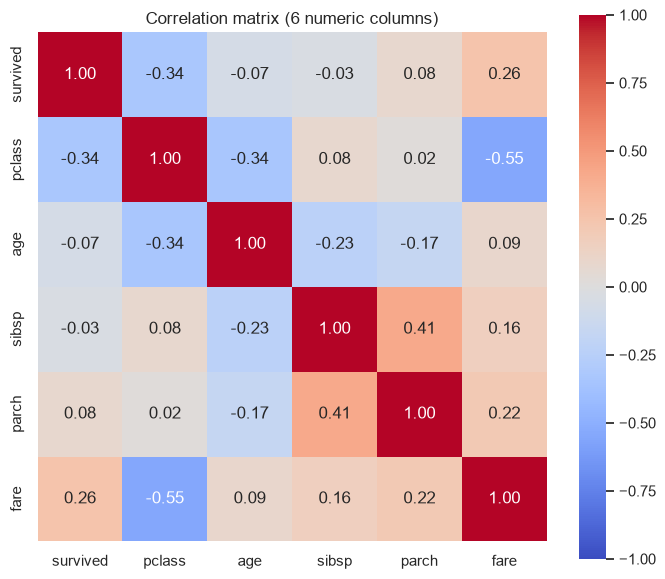

Top-2 |off-diagonal| correlations:
  pclass vs fare: -0.548
  sibsp vs parch: 0.415


In [9]:
# Correlation matrix on EXACTLY the six specified numeric columns.
# adult_male and alone are excluded (derived/redundant boolean flags).
cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = work[cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout(); plt.savefig("fig_corr_heatmap.png", dpi=120); plt.show()

# Rank off-diagonal pairs by absolute correlation.
pairs = [(cols[i], cols[j], corr.iloc[i, j])
         for i in range(len(cols)) for j in range(i + 1, len(cols))]
pairs.sort(key=lambda t: abs(t[2]), reverse=True)
print("Top-2 |off-diagonal| correlations:")
for a, b, c in pairs[:2]:
    print(f"  {a} vs {b}: {c:.3f}")

### Task 4 interpretation
**Survival rates.** By sex, survival is starkly gendered: **female 74.04%** vs
**male 18.89%**. By class it falls monotonically with lower class:
**1st 62.62%, 2nd 47.28%, 3rd 24.24%**. The interaction is sharpest of all:
**1st-class women 96.74%** and **2nd-class women 92.11%** almost all survived,
while **2nd- and 3rd-class men (15.74% / 13.54%)** almost all died. "Women and
children first" clearly operated, strongly amplified by class.

**Two strongest correlations** (largest absolute off-diagonal coefficients):
1. **pclass vs fare = -0.548** - lower class number (1st) means much higher fare,
   as expected since class is priced.
2. **sibsp vs parch = +0.415** - passengers travelling with siblings/spouses also
   tended to travel with parents/children, i.e. families boarded together.

## Task 5 - Multivariate data story (>= 4 charts, each interpreted)

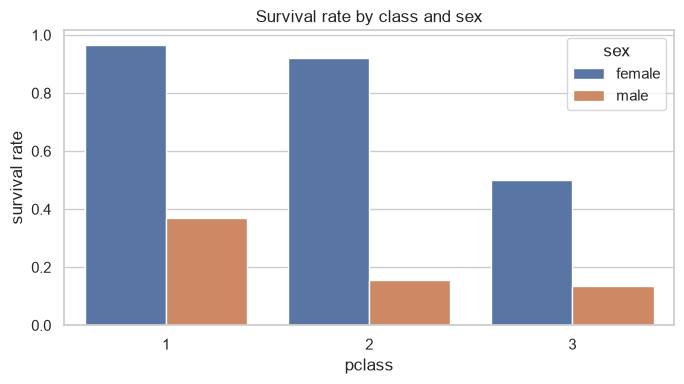

In [10]:
# Chart 1: survival rate by sex and class (bar)
plt.figure(figsize=(7, 4))
sns.barplot(data=work, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival rate by class and sex"); plt.ylabel("survival rate")
plt.tight_layout(); plt.savefig("fig1_survival_class_sex.png", dpi=120); plt.show()

**Chart 1 - Survival by class and sex.** Within every class women survive far more
than men, and the gap plus the level both worsen as class drops. First-class women
are near-certain to survive while third-class men are near-certain to die. Sex is
the dominant factor and class is a strong second, consistent with the correlations.

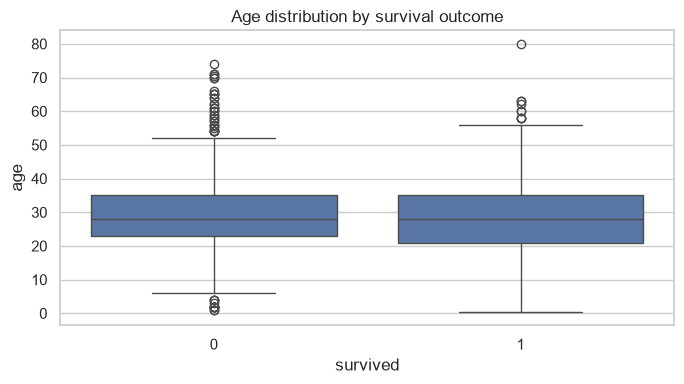

In [11]:
# Chart 2: age distribution by survival (box)
plt.figure(figsize=(7, 4))
sns.boxplot(data=work, x="survived", y="age")
plt.title("Age distribution by survival outcome")
plt.tight_layout(); plt.savefig("fig2_age_box.png", dpi=120); plt.show()

**Chart 2 - Age by survival.** The median age of survivors and non-survivors is
similar (both near 28), so age alone barely separates the classes - matching the
weak survived-age correlation (-0.07). The visible young outliers among survivors
hint that children had an edge, but age is a far weaker signal than sex or class.

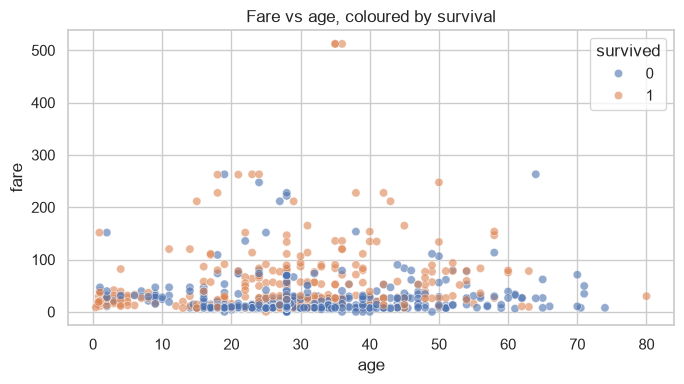

In [12]:
# Chart 3: fare vs age coloured by survival (scatter)
plt.figure(figsize=(7, 4))
sns.scatterplot(data=work, x="age", y="fare", hue="survived", alpha=0.6)
plt.title("Fare vs age, coloured by survival")
plt.tight_layout(); plt.savefig("fig3_fare_age_scatter.png", dpi=120); plt.show()

**Chart 3 - Fare vs age by survival.** Higher-fare passengers (top of the chart)
are visibly more often survivors (fare-survived correlation +0.26), reinforcing
that wealth/class bought safety. The dense low-fare band contains most of the
non-survivors, spread across all ages.

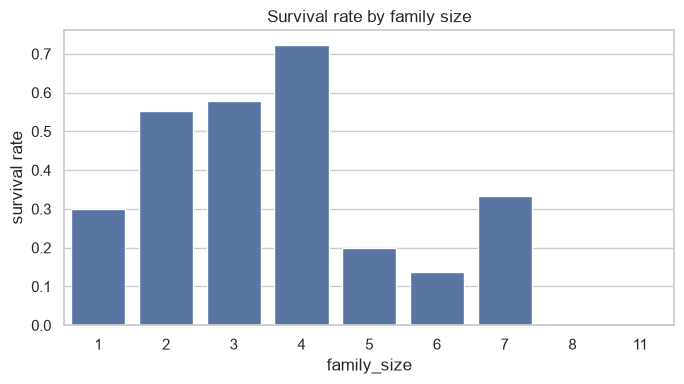

In [13]:
# Chart 4: survival count by family size (derived) (bar)
work["family_size"] = work["sibsp"] + work["parch"] + 1
plt.figure(figsize=(7, 4))
sns.barplot(data=work, x="family_size", y="survived", errorbar=None)
plt.title("Survival rate by family size"); plt.ylabel("survival rate")
plt.tight_layout(); plt.savefig("fig4_family_size.png", dpi=120); plt.show()

**Chart 4 - Family size.** Survival is highest for small families (size 2-4) and
lowest for solo travellers and very large families (5+). Small groups could help
each other reach boats, while large families struggled to stay together and lone
passengers had no advocate - a non-linear effect the raw sibsp/parch columns hide.

## Task 6 - Exploratory z-score standardization (sanity check only)

In [14]:
# EDA-stage check only; does NOT feed the modeling pipeline (that scales on train only).
before = work[["age", "fare"]].agg(["mean", "std"]).round(3)
z = (work[["age", "fare"]] - work[["age", "fare"]].mean()) / work[["age", "fare"]].std()
after = z.agg(["mean", "std"]).round(6)
print("BEFORE standardization (mean/std):"); print(before.to_string())
print("\nAFTER standardization (mean/std):"); print(after.to_string())

BEFORE standardization (mean/std):
         age    fare
mean  29.315  32.097
std   12.985  49.698

AFTER standardization (mean/std):
      age  fare
mean  0.0   0.0
std   1.0   1.0


### Task 6 interpretation
After z-scoring, both `age` and `fare` have **mean ~ 0** (order 1e-16) and
**std = 1.000**, confirming the transform worked. This is purely an EDA sanity
check: the modeling pipeline in `02_modeling.ipynb` fits its `StandardScaler`
on the **training split only** to avoid leakage, so this full-data scaling is not
reused downstream.

---
### EDA summary
Sex and class are the dominant survival drivers, amplified in interaction; fare
(a class proxy) helps, age barely does, and family size shows a non-linear sweet
spot. The raw dataset is saved as `titanic.csv`; `02_modeling.ipynb` continues
from that same committed file.